In [ ]:

# Comparative Analysis of ML Classifiers for Medical Diagnosis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
# Load Dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target

print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

print("\nFirst Five Rows")
display(df.head())

print("\nMissing Values")
print(df.isnull().sum())

# Correlation Analysis
correlation = df.corr()["target"].sort_values(ascending=False)

print("\nTop 5 Features Most Correlated With Target\n")
print(correlation[1:6])

# Feature & Target

X = df.drop("target", axis=1)
y = df["target"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData Preprocessing Completed Successfully.")

Dataset Shape : (569, 31)

First Five Rows


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Missing Values
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Top 5 Features Most Correlated With Target

smoothness error           

In [ ]:

# Step 2 : Model Training

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)


rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)


svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)

# Performance Table

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        svm_accuracy
    ],

    "Precision":[
        lr_precision,
        rf_precision,
        svm_precision
    ],

    "Recall":[
        lr_recall,
        rf_recall,
        svm_recall
    ]

})

print(results)

                    Model  Accuracy  Precision    Recall
0     Logistic Regression  0.973684   0.972222  0.985915
1           Random Forest  0.964912   0.958904  0.985915
2  Support Vector Machine  0.982456   0.972603  1.000000


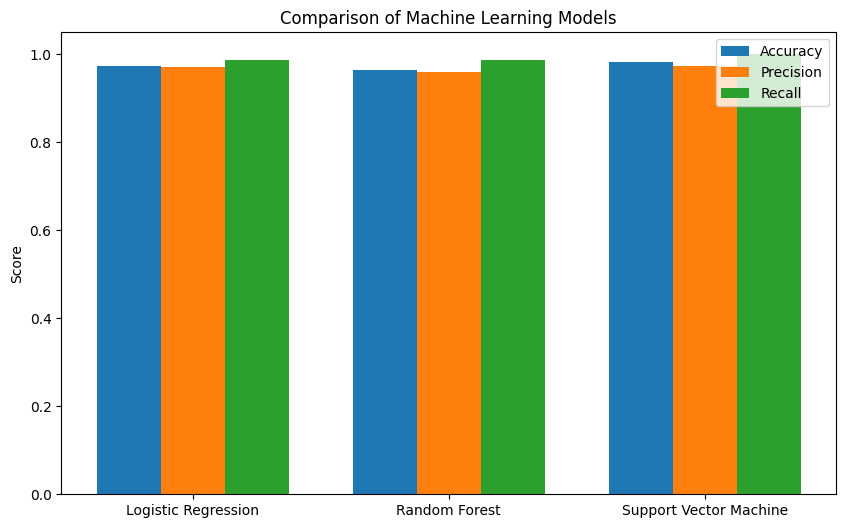

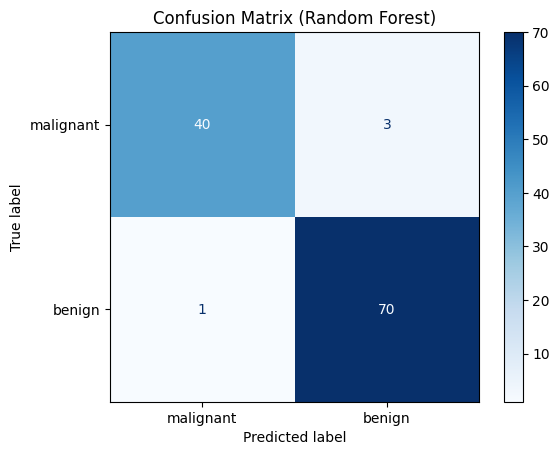

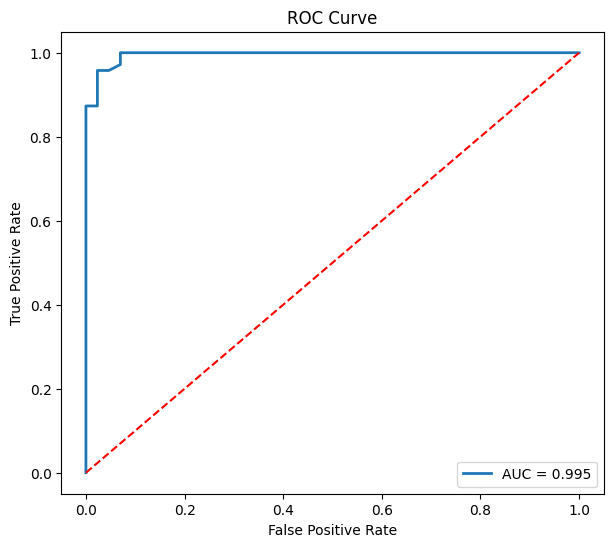

In [ ]:

# Step 3 : Visualization


models = results["Model"]

accuracy = results["Accuracy"]

precision = results["Precision"]

recall = results["Recall"]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x-width, accuracy, width, label="Accuracy")

plt.bar(x, precision, width, label="Precision")

plt.bar(x+width, recall, width, label="Recall")

plt.xticks(x, models)

plt.ylabel("Score")

plt.title("Comparison of Machine Learning Models")

plt.legend()

plt.show()

# ---------------- Confusion Matrix ----------------

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix (Random Forest)")

plt.show()

# ---------------- ROC Curve ----------------

prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2, label="AUC = %0.3f"%roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:

# Final Performance Summary

print("="*60)
print("Final Model Comparison")
print("="*60)

display(results.sort_values(by="Accuracy", ascending=False))

best_model = results.iloc[
    results["Accuracy"].idxmax()
]["Model"]

print("\nBest Performing Model :", best_model)

Final Model Comparison


,Model,Accuracy,Precision,Recall
2,Support Vector Machine,0.982456,0.972603,1.000000
0,Logistic Regression,0.973684,0.972222,0.985915
1,Random Forest,0.964912,0.958904,0.985915



Best Performing Model : Support Vector Machine
